In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D 
import numpy as np
from sklearn.cluster import DBSCAN

In [2]:
pd.set_option('display.max_columns', 30)

In [3]:
all_data = pd.read_csv("../../data/resample_normalized.csv")

In [4]:
variable_utiles = ["M_H", "VMICRO", "VMACRO", 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 
    'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H']

In [5]:
data=all_data[variable_utiles]

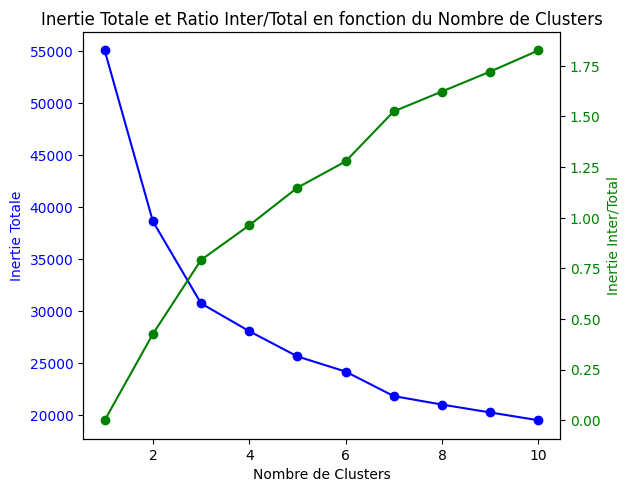

In [14]:
# Calcul de l'inertie pour différents nombres de clusters
inter_inertia_values = []
total_inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    
    # Inertie totale
    total_inertia = kmeans.inertia_
    total_inertia_values.append(total_inertia)
    
    # Calcul de l'inertie inter
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    # Centroid global (moyenne de tous les points)
    global_centroid = np.mean(data, axis=0)
    
    # Calcul de l'inertie inter
    inter_inertia = 0
    for i in range(k):
        # Points dans le cluster i
        cluster_points = data[labels == i]
        # Nombre de points dans le cluster i
        n_i = cluster_points.shape[0]
        # Distance entre le centroid du cluster et le centroid global
        inter_inertia += n_i * np.linalg.norm(centroids[i] - global_centroid)**2
    
    inter_inertia_values.append(inter_inertia)

# Calcul du ratio Inertie Inter / Inertie Totale
inter_total_ratio = [inter / total if total != 0 else 0 for inter, total in zip(inter_inertia_values, total_inertia_values)]

# Tracer l'inertie totale et le ratio Inter/Total
fig, ax1 = plt.subplots()

ax1.plot(K_range, total_inertia_values, marker='o', color='blue', label='Inertie Totale')
ax1.set_xlabel('Nombre de Clusters')
ax1.set_ylabel('Inertie Totale', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(K_range, inter_total_ratio, marker='o', color='green', label='Inertie Inter/Total')
ax2.set_ylabel('Inertie Inter/Total', color='green')
ax2.tick_params(axis='y', labelcolor='green')

fig.tight_layout()
plt.title('Inertie Totale et Ratio Inter/Total en fonction du Nombre de Clusters')
plt.show()


In [17]:
# Nombre de clusters (K) à définir, ajustez selon votre problème
k = 4  # Exemple pour 4 clusters

# Appliquer KMeans
kmeans = KMeans(n_clusters=k, random_state=42)  # random_state pour la reproductibilité
kmeans.fit(data)  # Entrée des données normalisées

# Obtenir les labels des clusters (indices de chaque cluster pour chaque point)
labels = kmeans.labels_

# Ajouter les labels au dataframe pour faciliter l'analyse
data['Cluster'] = labels

C:\Users\axioz\AppData\Local\Temp\ipykernel_7364\16082592.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = labels


Cluster
1    156430
2    114266
0    111385
3     71871
Name: count, dtype: int64


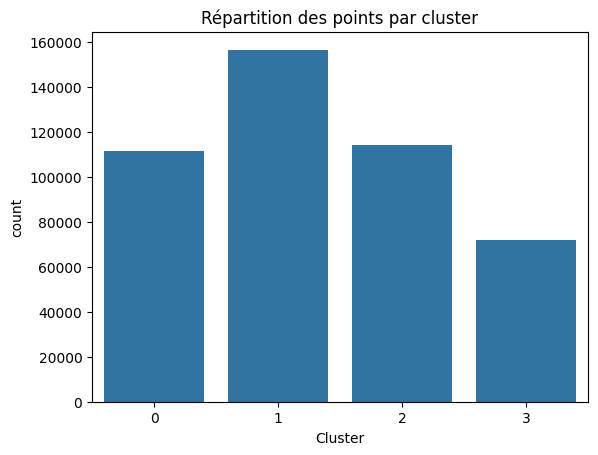

In [18]:
# Comptage du nombre de points dans chaque cluster
cluster_counts = data['Cluster'].value_counts()
print(cluster_counts)

# Visualisation de la répartition des clusters
import seaborn as sns
sns.countplot(x='Cluster', data=data)
plt.title("Répartition des points par cluster")
plt.show()

In [19]:
# Affichage des centroids des clusters
centroids = kmeans.cluster_centers_

# Exclure la colonne 'Cluster' en utilisant la méthode drop
centroid_df = pd.DataFrame(centroids, columns=data.drop('Cluster', axis=1).columns)

print(centroid_df)

        M_H    VMICRO        VMACRO      C_FE     CI_FE      N_FE      O_FE  \
0  0.800362  0.195794  2.529016e-01  0.614302  0.563545  0.358730  0.457188   
1  0.748189  0.090015  2.059741e-13  0.618794  0.599090  0.279110  0.483610   
2  0.663059  0.264096  3.238877e-01  0.608395  0.573689  0.342186  0.504053   
3  0.560300  0.256956  3.759299e-01  0.641264  0.630424  0.317350  0.625666   

      NA_FE     MG_FE     AL_FE     SI_FE      S_FE      K_FE     CA_FE  \
0  0.589802  0.485660  0.475735  0.421411  0.460513  0.627935  0.469421   
1  0.558404  0.491227  0.516638  0.452888  0.453312  0.628669  0.481971   
2  0.570019  0.526481  0.499736  0.449787  0.508993  0.640694  0.494767   
3  0.575066  0.657934  0.546773  0.543335  0.621444  0.681986  0.561944   

      TI_FE      V_FE     CR_FE     MN_FE     NI_FE      FE_H  
0  0.518990  0.496208  0.649130  0.584014  0.624108  0.803715  
1  0.444729  0.507968  0.617218  0.570774  0.621601  0.753496  
2  0.491513  0.509497  0.640626  0.5

In [20]:
#VMicro/VMacro très importants, 
#3ème cluster souvent différent des 1,2,4 qui sont proches

In [21]:
# Ajouter la colonne 'Cluster' à vos données
data['Cluster'] = kmeans.labels_

# Calculer l'écart-type de chaque colonne par cluster
cluster_dispersion = data.groupby('Cluster').std()  # Ecart-type pour chaque cluster
print(cluster_dispersion)

              M_H    VMICRO    VMACRO      C_FE     CI_FE      N_FE      O_FE  \
Cluster                                                                         
0        0.050935  0.071238  0.042235  0.035532  0.040364  0.049769  0.033675   
1        0.074180  0.096595  0.000000  0.036826  0.040772  0.084594  0.071579   
2        0.054039  0.080575  0.043023  0.043805  0.047778  0.044675  0.045188   
3        0.107869  0.086817  0.115545  0.069397  0.064040  0.075426  0.055158   

            NA_FE     MG_FE     AL_FE     SI_FE      S_FE      K_FE     CA_FE  \
Cluster                                                                         
0        0.041493  0.036523  0.026922  0.022266  0.038988  0.031639  0.028399   
1        0.102644  0.067318  0.039471  0.038328  0.066738  0.036771  0.043419   
2        0.053406  0.046707  0.044136  0.029860  0.055344  0.030005  0.026073   
3        0.078402  0.047823  0.067533  0.036980  0.078363  0.032440  0.039550   

            TI_FE      V_F

C:\Users\axioz\AppData\Local\Temp\ipykernel_7364\2092512363.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = kmeans.labels_


In [22]:
# Calcul des statistiques descriptives par cluster
cluster_stats = data.groupby('Cluster').describe()
print(cluster_stats)

              M_H                                                              \
            count      mean       std       min       25%       50%       75%   
Cluster                                                                         
0        111385.0  0.800433  0.050935  0.586651  0.760286  0.793722  0.835226   
1        156430.0  0.748177  0.074180  0.343316  0.698990  0.753903  0.800401   
2        114266.0  0.663196  0.054039  0.142263  0.629506  0.671459  0.704424   
3         71871.0  0.560051  0.107869  0.000000  0.525042  0.585615  0.634173   

                     VMICRO                                                    \
              max     count      mean       std       min       25%       50%   
Cluster                                                                         
0        1.000000  111385.0  0.195812  0.071238  0.000000  0.168495  0.207453   
1        0.967305  156430.0  0.090006  0.096595  0.000000  0.009925  0.051121   
2        0.828722  114266.0

In [13]:
# Calcul du score de silhouette
#silhouette_avg = silhouette_score(data, kmeans.labels_)
#print(f"Score de silhouette : {silhouette_avg}")

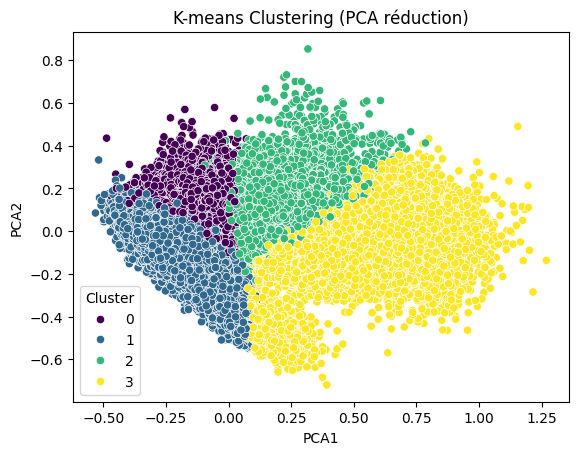

In [23]:
# Réduction de dimensionnalité à 2D avec PCA pour la visualisation
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data.drop('Cluster', axis=1))

# Créer un DataFrame avec les nouvelles dimensions et les labels
data_pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
data_pca_df['Cluster'] = data['Cluster']

# Visualisation
sns.scatterplot(x=data_pca_df['PCA1'], y=data_pca_df['PCA2'], hue=data_pca_df['Cluster'], palette='viridis')
plt.title('K-means Clustering (PCA réduction)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
'''import plotly.express as px
from sklearn.decomposition import PCA

# Réduction de dimensionnalité à 3D avec PCA
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data.drop('Cluster', axis=1))

# Créer un DataFrame avec les nouvelles dimensions et les labels
data_pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2', 'PCA3'])
data_pca_df['Cluster'] = data['Cluster']

# Créer un graphique 3D interactif avec Plotly
fig = px.scatter_3d(data_pca_df, x='PCA1', y='PCA2', z='PCA3', color='Cluster', title="3D PCA plot")

# Afficher le graphique interactif
fig.show()

ModuleNotFoundError: No module named 'plotly'

In [ ]:
# DBSCAN

In [6]:
echantillon = data.sample(frac=0.1, random_state=42)  # 10% des données

In [28]:
# Appliquer DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=10)  # Ajuste ces paramètres en fonction de ton dataset
labels = dbscan.fit_predict(echantillon)

In [29]:
# Ajouter les labels au dataframe
echantillon['Cluster'] = labels

# Afficher les clusters trouvés
print(echantillon['Cluster'].value_counts())

Cluster
 2    15495
 1    11287
 0    11064
 3     6600
-1      645
 4      304
Name: count, dtype: int64


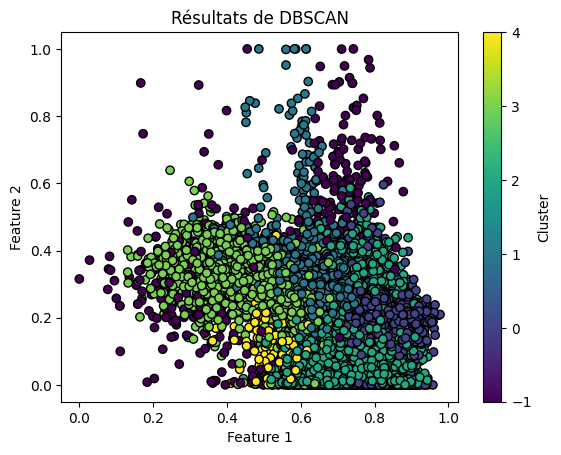

In [32]:
import matplotlib.pyplot as plt

# Scatter plot avec couleur selon le cluster
plt.scatter(echantillon.to_numpy()[:, 0], echantillon.to_numpy()[:, 1], c=labels, cmap='viridis', marker='o', edgecolors='k')

plt.title("Résultats de DBSCAN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()


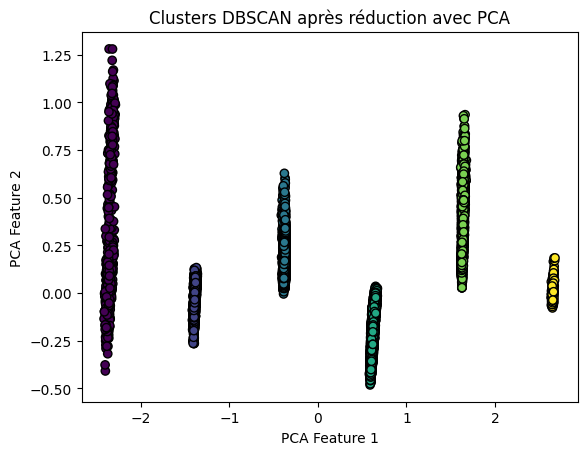

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(echantillon)  # Réduit à 2 dimensions

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', marker='o', edgecolors='k')
plt.title("Clusters DBSCAN après réduction avec PCA")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.show()

In [1]:
#Skope-rules

In [6]:
import collections.abc
import six
import sklearn
collections.Iterable = collections.abc.Iterable
sklearn.externals.six = six
from skrules import SkopeRules

In [13]:
X = all_data[variable_utiles].values  # Extraction des variables utiles

y = all_data['class_spectral']  # Supposons que votre dataset a une colonne cible "target"

clf = SkopeRules(max_depth_duplication=2,
                 n_estimators=30,
                 precision_min=0.3,
                 recall_min=0.1,
                 feature_names=variable_utiles)

# On entraîne un modèle pour chaque classe présente dans y
for idx in sorted(set(y)):
    clf.fit(X, y == idx)
    rules = clf.rules_[0:3]
    print(f"Rules for class {idx}")
    for rule in rules:
        print(rule)
    print('\n' + '=' * 20 + '\n')

c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encounter

Rules for class F
('VMICRO > 0.16186175495386124 and SI_FE > 0.4301436245441437 and MG_FE <= 0.4351128786802292', (np.float64(0.7189235477837953), np.float64(0.3403355612998907), 2))
('VMACRO <= 0.09647909551858902 and N_FE > 0.4475620985031128 and MG_FE > 0.4326455444097519', (np.float64(0.7821080602302923), np.float64(0.13583918773396236), 1))
('N_FE <= 0.1338140070438385 and MG_FE > 0.43003328144550323', (np.float64(0.4143163156015709), np.float64(0.11873337425823614), 1))




c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encounter

Rules for class G
('VMICRO <= 0.22922909259796143 and TI_FE <= 0.45725099742412567 and VMACRO <= 0.0918133556842804', (np.float64(0.7699274332594404), np.float64(0.5572453135499088), 1))
('TI_FE > 0.4563274383544922 and VMACRO <= 0.09376773983240128 and AL_FE > 0.5186273157596588', (np.float64(0.5704163512490538), np.float64(0.2580053140493604), 1))




c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encountered in scalar add
  if sum(mask) == 0:
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\skrules\skope_rules.py:338: RuntimeWarning: overflow encounter

Rules for class K
('VMACRO > 0.0918133556842804 and N_FE <= 0.4211026579141617 and O_FE > 0.301675483584404', (np.float64(0.9978498468965825), np.float64(0.824751714353275), 1))
('TI_FE > 0.4431851804256439 and CR_FE > 0.6269320845603943 and VMACRO <= 0.0918133556842804', (np.float64(0.576271186440678), np.float64(0.10497198801966194), 1))




In [ ]:
'''skope rules 

Rules for class F
('VMICRO > 0.16186175495386124 and SI_FE > 0.4301436245441437 and MG_FE <= 0.4351128786802292', (np.float64(0.7189235477837953), np.float64(0.3403355612998907), 2))
('VMACRO <= 0.09647909551858902 and N_FE > 0.4475620985031128 and MG_FE > 0.4326455444097519', (np.float64(0.7821080602302923), np.float64(0.13583918773396236), 1))
('N_FE <= 0.1338140070438385 and MG_FE > 0.43003328144550323', (np.float64(0.4143163156015709), np.float64(0.11873337425823614), 1))




Rules for class G
('VMICRO <= 0.22922909259796143 and TI_FE <= 0.45725099742412567 and VMACRO <= 0.0918133556842804', (np.float64(0.7699274332594404), np.float64(0.5572453135499088), 1))
('TI_FE > 0.4563274383544922 and VMACRO <= 0.09376773983240128 and AL_FE > 0.5186273157596588', (np.float64(0.5704163512490538), np.float64(0.2580053140493604), 1))

====================

Rules for class K
('VMACRO > 0.0918133556842804 and N_FE <= 0.4211026579141617 and O_FE > 0.301675483584404', (np.float64(0.9978498468965825), np.float64(0.824751714353275), 1))
('TI_FE > 0.4431851804256439 and CR_FE > 0.6269320845603943 and VMACRO <= 0.0918133556842804', (np.float64(0.576271186440678), np.float64(0.10497198801966194), 1))


In [7]:
# Tester kmedoids ? Peut être long

In [9]:
import hdbscan

In [10]:
from packaging import version
arg = "force_all_finite" if version.parse(sklearn.__version__) < version.parse("1.6") else "ensure_all_finite"

NameError: name 'sklearn' is not defined

In [11]:
# Initialisation du modèle HDBSCAN
hdbscan_cluster = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)

# Ajustement du modèle et prédiction des clusters
labels = hdbscan_cluster.fit_predict(echantillon)

# Affichage des résultats
np.unique(labels, return_counts=True)

c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8]),
 array([ 5509, 14921,    14,    12,    11,    19,    17, 24846,    13,
           33]))

In [12]:
hdbscan_cluster.probabilities_

array([1.        , 0.78404642, 1.        , ..., 1.        , 1.        ,
       1.        ])